In [1]:
import os

#add the root directory
os.chdir('../')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from loader import *
import h5py
from sklearn.metrics import mean_squared_error
import seaborn as sns
import pickle
import io

from datetime import datetime

from ANN_regression import *
from torchdiffeq import odeint
from matplotlib.ticker import LogLocator
from matplotlib.lines import Line2D
import matplotlib.cm as cm
from matplotlib.ticker import ScalarFormatter
from matplotlib.patches import FancyArrowPatch, Ellipse
import matplotlib.lines as mlines

from matplotlib.legend_handler import HandlerBase
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import FuncFormatter
from matplotlib.ticker import FixedLocator, NullFormatter

<h2> Supplementary material: Error accumulation analysis

Comparison of the heuristic PV H2O-H2-O2 and the optimized PV during the a posteriori analysis. Understand how the error accumulates over time.

<h3> Prepare all the datasets

In [3]:
filename_autoignition = "isochoric-adiabatic-closed-HR-H2-air-lin_Z_0.015_0.035_100-T0_900-"
path_data_autoignition = "data-files/autoignition/"
path_data = "data-files/"
regression_modelname = "Xu_2026-01-20_14h18_s7"   #handles negative values with abs, 300k epo without minibatching
regression_modelname_optimized = "Optimized_Tr0D-2s_s2_2026-01-20_16h11_s7" #handles negative values with abs, 300k epo without minibatching

regression_full_modelname = "Xu_full_2026-01-26_15h29" #With rectangular manifold
regression_full_modelname_optimized = "Optimized_full_Tr0D-2s_s2_2026-01-26_16h02" #rectangular manifold now

path_regression_model = "paper/models/"

## Define the global datasets

In [4]:
#create all the datasets
mixture_fractions_test = np.loadtxt(f"{path_data_autoignition}{filename_autoignition}mixture-fractions-test-trajectories.csv") #1 x nbr_test_trajectories
state_space_names = np.genfromtxt(f"{path_data_autoignition}{filename_autoignition}state-space-names.csv", delimiter=",", dtype=str)

---
<h3> Heuristic PV: PV source term model - f-PV to PV source

In [5]:
class CPU_Unpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if module == 'torch.storage' and name == '_load_from_bytes':
            return lambda b: torch.load(io.BytesIO(b), map_location='cpu')
        return super().find_class(module, name)

with open(f'{path_regression_model}{regression_modelname}_metadata.pkl', 'rb') as f:
    loaded_dict = CPU_Unpickler(f).load()
    
model_params = loaded_dict["model_params"]

mins_input_Xu = loaded_dict["mins_input"]
maxs_input_Xu = loaded_dict["maxs_input"]
mins_output_Xu = loaded_dict["mins_output"]
maxs_output_Xu = loaded_dict["maxs_output"]

PV_Xu_source_min_train = loaded_dict["PV_Xu_source_min_train"]
log_PVsource = loaded_dict["log_PVsource"]
epsilon = loaded_dict["epsilon"]
Xu_H2O = loaded_dict["Xu_H2O"] #"Xu"
log_transform = loaded_dict["log transformation"]
scaledManifold_Xu = loaded_dict["scaled manifold"]

model_regression_Xu = ANN_regression(**model_params)
model_regression_Xu.load_state_dict(torch.load(f"{path_regression_model}{regression_modelname}_model.pth", weights_only=False, map_location=torch.device('cpu')))

def inverse_symlog(x_prime, threshold):
    return np.sign(x_prime) * threshold * (10 ** np.abs(x_prime) - 1)

C:\Windows\Temp\ipykernel_29948\359117153.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return lambda b: torch.load(io.BytesIO(b), map_location='cpu')


In [6]:
prediction_test_trajectories = []

for i in range(10):
    #test state space
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-test-trajectories.h5", 'r') as hf:
        test_trajectory = pd.DataFrame(hf[f'test_trajectory_{i}'][:], columns = state_space_names)
        if(Xu_H2O == "H2O"):
            PV_Xu_test = test_trajectory["H2O"]
        elif(Xu_H2O == "Xu"):
            PV_Xu_test = test_trajectory["H2O"] - test_trajectory["H2"] - test_trajectory["O2"]
        elif(Xu_H2O == "heuSoph10HO2"):
            PV_Xu_test = test_trajectory["H2O"] + 10 * test_trajectory["HO2"]
        PV_Xu_test = PV_Xu_test.to_numpy().reshape(-1,1)

        if(scaledManifold_Xu):
            PV_Xu_test = (PV_Xu_test - PV_Xu_test.min())/(PV_Xu_test.max() - PV_Xu_test.min())
            #print(PV_Xu_test)

        f_PV_Xu_test = np.hstack((np.full(PV_Xu_test.shape[0], mixture_fractions_test[i]).reshape(-1,1), PV_Xu_test))
        f_PV_Xu_test_torch = torch.tensor(f_PV_Xu_test)
        f_PV_Xu_test_torch_scaled = (f_PV_Xu_test_torch - mins_input_Xu)/(maxs_input_Xu - mins_input_Xu) - 0.5
    
    #test source terms
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-sources-test-trajectories.h5", 'r') as hf:
        test_trajectory_source = pd.DataFrame(hf[f'test_trajectory_{i}'][:], columns = state_space_names)
        if(Xu_H2O == "H2O"):
            PV_Xu_source_test = test_trajectory_source["H2O"]
        elif(Xu_H2O == "Xu"):
            PV_Xu_source_test = test_trajectory_source["H2O"] - test_trajectory_source["H2"] - test_trajectory_source["O2"]
        elif(Xu_H2O == "heuSoph10HO2"):
            PV_Xu_source_test = test_trajectory_source["H2O"] + 10 * test_trajectory_source["HO2"]
        PV_Xu_source_test = PV_Xu_source_test.to_numpy()
    
    
    PV_Xu_source_test_predicted = model_regression_Xu(f_PV_Xu_test_torch_scaled)
    PV_Xu_source_test_predicted = (PV_Xu_source_test_predicted+1) /2 * (maxs_output_Xu - mins_output_Xu) + mins_output_Xu
    PV_Xu_source_test_predicted = PV_Xu_source_test_predicted.detach().numpy()
    if(log_PVsource):
        if(log_transform == "continuous-symlog"):
            PV_Xu_source_test_predicted = inverse_symlog(PV_Xu_source_test_predicted, epsilon)
        elif(log_transform == "log"):
            PV_Xu_source_test_predicted = 10**PV_Xu_source_test_predicted
    
    prediction_test_trajectories.append(PV_Xu_source_test_predicted)

    MSE_Xu_test = mean_squared_error(PV_Xu_source_test, PV_Xu_source_test_predicted)

    print(f"MSE of Xu for test trajectory {i}: {MSE_Xu_test}")
    

MSE of Xu for test trajectory 0: 5306586.295000174
MSE of Xu for test trajectory 1: 1872633.2848183797
MSE of Xu for test trajectory 2: 1601270.4551591042
MSE of Xu for test trajectory 3: 3607710.3756123534
MSE of Xu for test trajectory 4: 7028487.068438524
MSE of Xu for test trajectory 5: 10558955.23437965
MSE of Xu for test trajectory 6: 11937904.347299866
MSE of Xu for test trajectory 7: 10568721.147007642
MSE of Xu for test trajectory 8: 9927661.818661742
MSE of Xu for test trajectory 9: 15271497.403741347


C:\Windows\Temp\ipykernel_29948\1841236102.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  greys = cm.get_cmap('Greys')


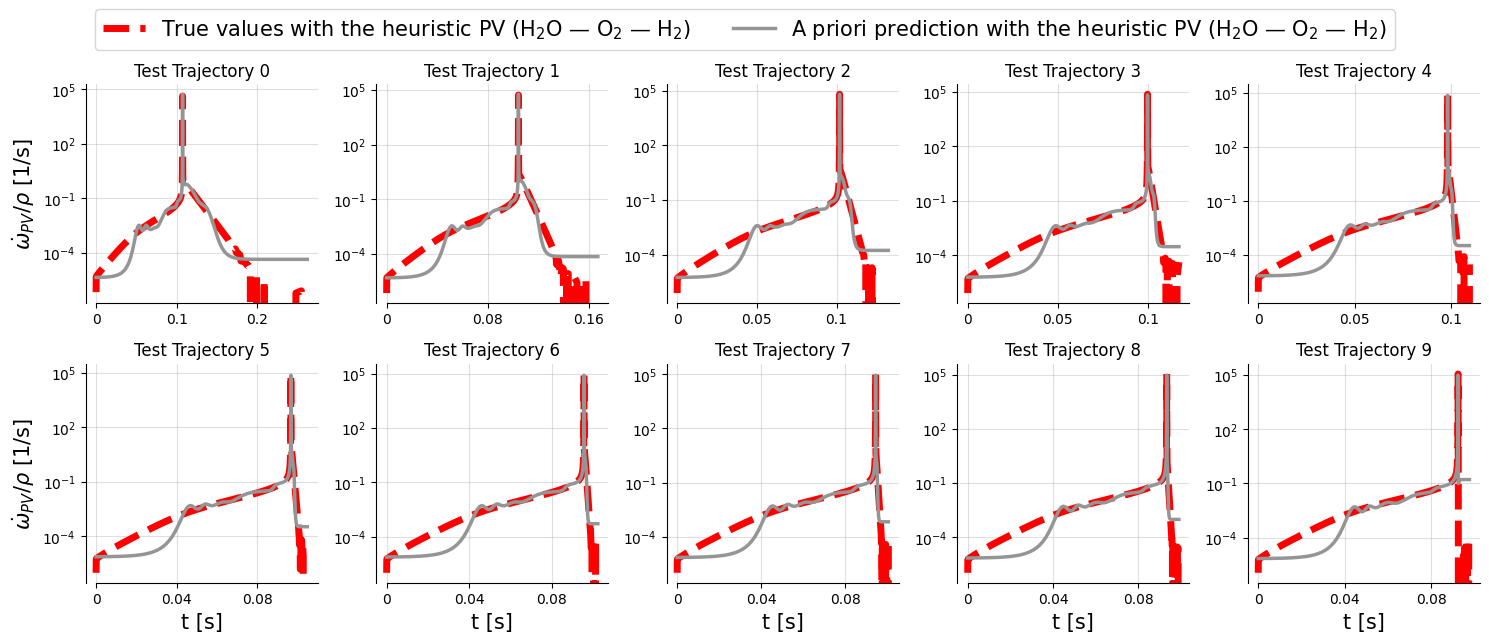

In [7]:
save = False
pathSave = "C:/Users/admin/Documents/PhD-ULB/Figures/2024-PV-optimization/Paper/EnergyAndAI/Supplementary-material/A posteriori/"
name = f"Apriori_ANN_{regression_modelname}.png"
namePdf = f"Apriori_ANN_{regression_modelname}.pdf"

num_test_trajectories = 10
rows, cols = 2, 5  # Arrange in a 2x5 grid

fig, axes = plt.subplots(rows, cols, figsize=(15, 6))  # Define the grid
axes = axes.flatten()  # Flatten to 1D array for easy indexing

greys = cm.get_cmap('Greys')

def zero_formatter(x, pos):
    if x == 0:
        return "0"
    else:
        return f"{x:g}"

for i in range(num_test_trajectories):  
    #test source terms
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-sources-test-trajectories.h5", 'r') as hf:
        test_trajectory_source = pd.DataFrame(hf[f'test_trajectory_{i}'][:], columns = state_space_names)
        PV_Xu_source_test = test_trajectory_source["H2O"] - test_trajectory_source["H2"] - test_trajectory_source["O2"]
        PV_Xu_source_test = PV_Xu_source_test.to_numpy()
    
    #test time trajectories
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}time-test-trajectories.h5", 'r') as hf:
        test_trajectory_time = pd.DataFrame(hf[f'test_trajectory_{i}'][:])

    ax = axes[i]
    ax.plot(test_trajectory_time, PV_Xu_source_test, label="True values with the heuristic PV (H$_2$O \u2014 O$_2$ \u2014 H$_2$)", color = "red", linestyle = "--", linewidth = 5)
    ax.plot(test_trajectory_time, prediction_test_trajectories[i], label="A priori prediction with the heuristic PV (H$_2$O \u2014 O$_2$ \u2014 H$_2$)", color = greys(0.5), linewidth = 2.5)
    ax.set_title(f"Test Trajectory {i}")
    ax.set_yscale("log")
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=2))
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=3))
    ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=6))
    ax.grid(True, linestyle='-', alpha=0.4)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    xmin, xmax = ax.get_xlim()
    ax.spines["bottom"].set_bounds(0, xmax)

    ax.xaxis.set_major_formatter(FuncFormatter(zero_formatter))
    
    if(i>=num_test_trajectories-cols):
            ax.set_xlabel(f"t [s]", fontsize = 15)
    
    if(i%cols == 0):
            ax.set_ylabel(r'$\dot{\omega}_{PV} / \rho$ [1/s]', fontsize = 15)

#hide empty figures
for j in range(num_test_trajectories, len(axes)):
    axes[j].axis("off")

handles, labels = axes[0].get_legend_handles_labels()
custom_handles = [
    Line2D([0], [0], color=handle.get_color(),
           linestyle=handle.get_linestyle(),
           linewidth=handle.get_linewidth() * 1,  # Increase legend linewidth
           label=label)
    for handle, label in zip(handles, labels)
]
fig.legend(custom_handles, labels, loc='upper center', ncol=2, fontsize=15, frameon=True, bbox_to_anchor=(0.5, 1.08))

# Adjust layout
plt.tight_layout()
if(save):
    plt.savefig(pathSave + name, dpi=300, bbox_inches = "tight")
    plt.savefig(pathSave + namePdf, bbox_inches = "tight")
plt.show()

---
<h3> Heuristic PV: Evolve the PV over time

In [ ]:
class ODEXu(torch.nn.Module):

    def __init__(self, min_max_PV):
        super().__init__()
        self.outputs = [] #list to store the predicted source terms
        self.min_PV = min_max_PV[0]
        self.max_PV = min_max_PV[1]

    def forward(self, t, y):
        
        y_scaled = y.clone() #avoid in place changes
        if scaledManifold_Xu:
            y_scaled[0, 1] = (y_scaled[0, 1] - self.min_PV)/(self.max_PV - self.min_PV)

        f_PV = (y_scaled-mins_input_Xu) / (maxs_input_Xu - mins_input_Xu) - 0.5
        PV_source_predicted = model_regression_Xu(f_PV)
        PV_source_predicted = (PV_source_predicted+1) /2 * (maxs_output_Xu - mins_output_Xu) + mins_output_Xu

        if(log_transform == "continuous-symlog"):
            PV_source_predicted = inverse_symlog(PV_source_predicted, epsilon)
        elif(log_transform == "log"):
            PV_source_predicted = 10**PV_source_predicted

        
        self.outputs.append(PV_source_predicted.detach().numpy())

        zero = torch.tensor([[0.0]], dtype=PV_source_predicted.dtype, device=PV_source_predicted.device)
        f_PV_source_predicted = torch.cat((zero, PV_source_predicted), dim=1) #add a zero for the mixture fraction

        return f_PV_source_predicted

In [90]:
idx_start_simulation = 0
list_simulations_Xu = []
list_predicted_PV_source = []

#Get current date and time
now = datetime.now()
date_str = now.strftime("%Y-%m-%d")
time_str = now.strftime("%Hh%M")

print("Date:", date_str)
print("Hour:", time_str)

for i in range(10):

    with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-test-trajectories.h5", 'r') as hf:
        test_trajectory = pd.DataFrame(hf[f'test_trajectory_{i}'][:], columns = state_space_names)
        if(Xu_H2O == "H2O"):
            PV_Xu_test = test_trajectory["H2O"]
        elif(Xu_H2O == "Xu"):
            PV_Xu_test = test_trajectory["H2O"] - test_trajectory["H2"] - test_trajectory["O2"]
        elif(Xu_H2O == "heuSoph10HO2"):
            PV_Xu_test = test_trajectory["H2O"] + 10 * test_trajectory["HO2"]

        PV_Xu_test = PV_Xu_test.to_numpy().reshape(-1,1)
        f_PV_Xu_test = np.hstack((np.full(PV_Xu_test.shape[0], mixture_fractions_test[i]).reshape(-1,1), PV_Xu_test))
    
    #test time trajectories
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}time-test-trajectories.h5", 'r') as hf:
        test_trajectory_time = pd.DataFrame(hf[f'test_trajectory_{i}'][:])

    initial_condition = f_PV_Xu_test[idx_start_simulation,:]
    initial_condition = torch.tensor(initial_condition).unsqueeze(0)

    t_coordinates = test_trajectory_time[idx_start_simulation:].to_numpy().ravel()
    t_coordinates = torch.tensor(t_coordinates)
    
    ODEXu_instance = ODEXu([PV_Xu_test.min(), PV_Xu_test.max()])
    numerical_solution_Xu = odeint(ODEXu_instance, initial_condition, t_coordinates) #, method="rk4")
    numerical_solution_Xu = numerical_solution_Xu.squeeze(1)
    list_simulations_Xu.append(numerical_solution_Xu)
    list_predicted_PV_source.append(ODEXu_instance.outputs)

    MSE_Xu_test_simulation = mean_squared_error(PV_Xu_test[idx_start_simulation:], numerical_solution_Xu[:,1].detach().numpy())

    print(f"MSE for test trajectory {i}: {MSE_Xu_test_simulation}")

Date: 2026-05-06
Hour: 16h05
MSE for test trajectory 0: 0.046128455196301724
MSE for test trajectory 1: 0.055497755986602185
MSE for test trajectory 2: 0.0645933718511446
MSE for test trajectory 3: 0.0736491081251268
MSE for test trajectory 4: 0.08232159658088957
MSE for test trajectory 5: 0.09026177037445111
MSE for test trajectory 6: 0.0972927635781538
MSE for test trajectory 7: 0.10331077642432253
MSE for test trajectory 8: 0.10840295543023701
MSE for test trajectory 9: 0.11279444711455372


Use the MSE to quantitatively assess the quality of the simulationsn take the average MSE?

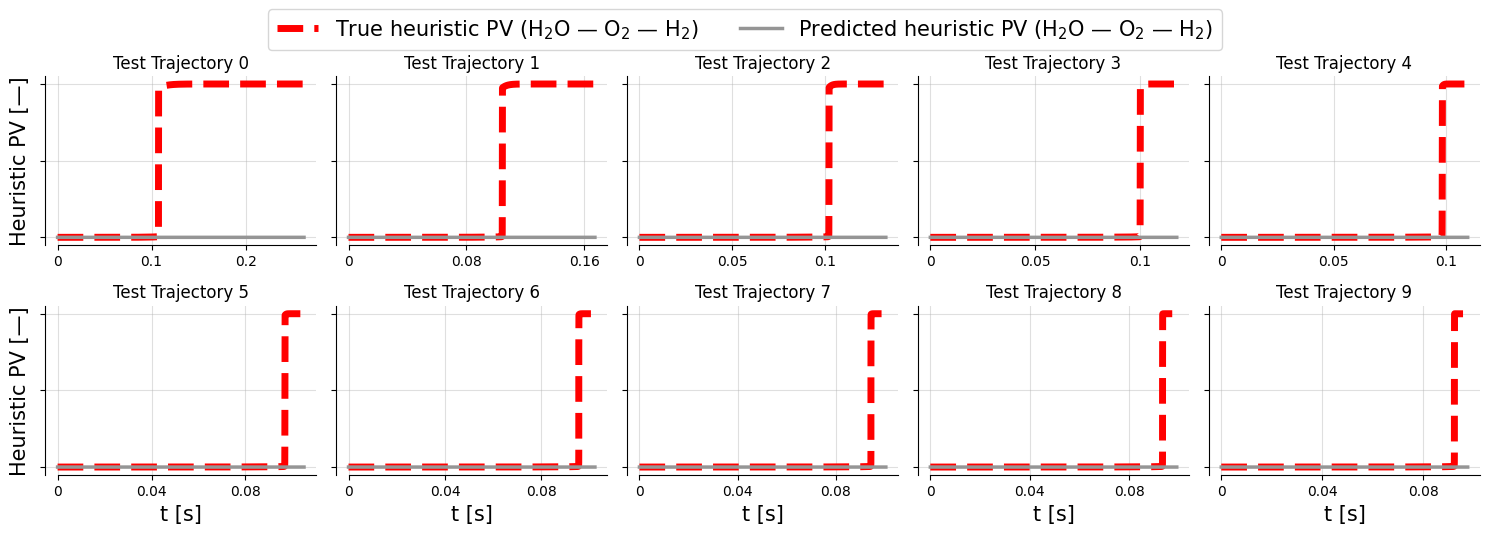

In [10]:
save = False
zoom = False
pathSave = "C:/Users/admin/Documents/PhD-ULB/Figures/2024-PV-optimization/Paper/EnergyAndAI/Supplementary-material/A posteriori/"

idx_start_simulation = 0

num_test_trajectories = 10
rows, cols = 2, 5 # Arrange in a 2x5 grid

fig, axes = plt.subplots(rows, cols, figsize=(15, 5))  # Define the grid
axes = axes.flatten()  # Flatten to 1D array for easy indexing

def zero_formatter(x, pos):
    if x == 0:
        return "0"
    else:
        return f"{x:g}"

for i in range(num_test_trajectories):
    #test state space
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-test-trajectories.h5", 'r') as hf:
        test_trajectory = pd.DataFrame(hf[f'test_trajectory_{i}'][:], columns = state_space_names)
        PV_Xu_test = test_trajectory["H2O"] - test_trajectory["H2"] - test_trajectory["O2"]
        PV_Xu_test = PV_Xu_test.to_numpy().reshape(-1,1)
        #PV_Xu_test = (PV_Xu_test - PV_Xu_test.min())/(PV_Xu_test.max() - PV_Xu_test.min())
        f_PV_Xu_test = np.hstack((np.full(PV_Xu_test.shape[0], mixture_fractions_test[i]).reshape(-1,1), PV_Xu_test))
    
    #test time trajectories
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}time-test-trajectories.h5", 'r') as hf:
        test_trajectory_time = pd.DataFrame(hf[f'test_trajectory_{i}'][:])
        
    ax = axes[i]

    PV_Xu_test_min = PV_Xu_test.min()
    PV_Xu_test_max = PV_Xu_test.max()

    if(zoom):
        ##############################################
        # Get the first and last index of the ignition
        ##############################################

        H2O_array = test_trajectory["H2O"].to_numpy()

        min_perc = 0.003
        max_perc = 0.995
        
        max_val = H2O_array.max()
        lower_threshold = min_perc * max_val
        upper_threshold = max_perc * max_val

        idx_1 = np.searchsorted(H2O_array, lower_threshold, side='left')
        idx_99 = np.searchsorted(H2O_array, upper_threshold, side='left')

        ax.plot(test_trajectory_time[idx_1:idx_99], (PV_Xu_test[idx_1:idx_99] - PV_Xu_test_min)/(PV_Xu_test_max - PV_Xu_test_min), label="True heuristic PV (H$_2$O \u2014 O$_2$ \u2014 H$_2$)", color = "red", linestyle = "--", linewidth = 5)
        ax.plot(test_trajectory_time[idx_1:idx_99], (list_simulations_Xu[i][idx_1:idx_99,1] - PV_Xu_test_min)/(PV_Xu_test_max - PV_Xu_test_min), label="Predicted heuristic PV (H$_2$O \u2014 O$_2$ \u2014 H$_2$)", color = greys(0.5), linewidth = 2.5)

    else:
        ax.plot(test_trajectory_time[idx_start_simulation:], (PV_Xu_test[idx_start_simulation:] - PV_Xu_test_min)/(PV_Xu_test_max - PV_Xu_test_min), label="True heuristic PV (H$_2$O \u2014 O$_2$ \u2014 H$_2$)", color = "red", linestyle = "--", linewidth = 5)
        ax.plot(test_trajectory_time[idx_start_simulation:], (list_simulations_Xu[i][:,1].detach().numpy() - PV_Xu_test_min)/(PV_Xu_test_max - PV_Xu_test_min), label="Predicted heuristic PV (H$_2$O \u2014 O$_2$ \u2014 H$_2$)", color = greys(0.5), linewidth = 2.5)
    
    ax.set_title(f"Test Trajectory {i}")
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=3))
    ax.set_yticks([0, 0.5, 1])
    ax.set_yticklabels([])
    ax.grid(True, linestyle='-', alpha=0.4)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    xmin, xmax = ax.get_xlim()
    ax.spines["bottom"].set_bounds(0, xmax)

    ax.xaxis.set_major_formatter(FuncFormatter(zero_formatter))
    
    if(i>=num_test_trajectories-cols):
            ax.set_xlabel(f"t [s]", fontsize = 15)
    
    if(i%cols == 0):
            ax.set_ylabel('Heuristic PV [\u2014]', fontsize = 15)

#hide empty figures
for j in range(num_test_trajectories, len(axes)):
    axes[j].axis("off")

handles, labels = axes[0].get_legend_handles_labels()
custom_handles = [
    Line2D([0], [0], color=handle.get_color(),
           linestyle=handle.get_linestyle(),
           linewidth=handle.get_linewidth() * 1,  # Increase legend linewidth
           label=label)
    for handle, label in zip(handles, labels)
]
fig.legend(custom_handles, labels, loc='upper center', ncol=2, fontsize=15, frameon=True, bbox_to_anchor=(0.5, 1.08))

name = f"Heuristic vs optimized - A posteriori - Heuristic PV - ANN {regression_modelname}{f' - zoom {min_perc}-{max_perc}' if zoom else ''}.png"
namePdf = f"Heuristic vs optimized - A posteriori - Heuristic PV - ANN {regression_modelname}{f' - zoom {min_perc}-{max_perc}' if zoom else ''}.pdf"

# Adjust layout
plt.tight_layout()
if(save):
    plt.savefig(pathSave + name, dpi=300, bbox_inches = "tight")
    plt.savefig(pathSave + namePdf, bbox_inches = "tight")
plt.show()

<h3> Run the a posteriori simulation longer

In [11]:
list_simulations_Xu_ext = []
list_predicted_PV_source_ext = []

#Get current date and time
now = datetime.now()
date_str = now.strftime("%Y-%m-%d")
time_str = now.strftime("%Hh%M")

print("Date:", date_str)
print("Hour:", time_str)

for i in range(10):

    with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-test-trajectories.h5", 'r') as hf:
        test_trajectory = pd.DataFrame(hf[f'test_trajectory_{i}'][:], columns = state_space_names)
        if(Xu_H2O == "H2O"):
            PV_Xu_test = test_trajectory["H2O"]
        elif(Xu_H2O == "Xu"):
            PV_Xu_test = test_trajectory["H2O"] - test_trajectory["H2"] - test_trajectory["O2"]
        
        PV_Xu_test = PV_Xu_test.to_numpy().reshape(-1,1)
        f_PV_Xu_test = np.hstack((np.full(PV_Xu_test.shape[0], mixture_fractions_test[i]).reshape(-1,1), PV_Xu_test))
    
    #test time trajectories
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}time-test-trajectories.h5", 'r') as hf:
        test_trajectory_time = pd.DataFrame(hf[f'test_trajectory_{i}'][:])

    initial_condition = f_PV_Xu_test[0,:]
    initial_condition = torch.tensor(initial_condition).unsqueeze(0)

    t_coordinates = test_trajectory_time[0:].to_numpy().ravel()
    t_coordinates = torch.tensor(t_coordinates)
    deltaTime = t_coordinates[-1] - t_coordinates[-2]

    last_value = t_coordinates[-1]
    new_times = []

    next_time = last_value + deltaTime
    while next_time <= 2:
        new_times.append(next_time.item())
        next_time += deltaTime

    #Add extension to the current tensor
    if new_times:
        extension = torch.tensor(new_times, dtype=torch.float32)
        t_coordinates = torch.cat((t_coordinates, extension))
    
    ODEXu_instance = ODEXu([PV_Xu_test.min(), PV_Xu_test.max()])
    numerical_solution_Xu = odeint(ODEXu_instance, initial_condition, t_coordinates) #, method="rk4")
    numerical_solution_Xu = numerical_solution_Xu.squeeze(1)
    list_simulations_Xu_ext.append(numerical_solution_Xu)
    list_predicted_PV_source_ext.append(ODEXu_instance.outputs)

Date: 2026-05-06
Hour: 11h38


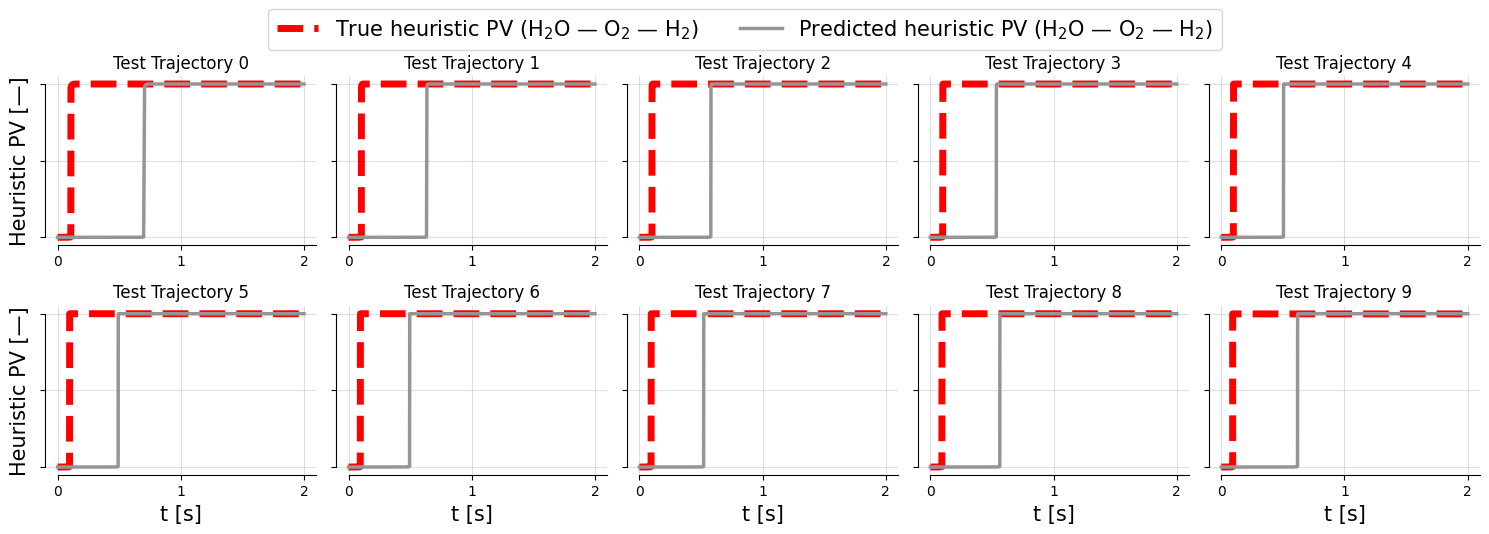

In [12]:
save = False
zoom = False
pathSave = "C:/Users/admin/Documents/PhD-ULB/Figures/2024-PV-optimization/Paper/EnergyAndAI/Supplementary-material/A posteriori/"
name = f"Heuristic vs optimized - A posteriori - Heuristic PV - ANN {regression_modelname}{f' - zoom {min_perc}-{max_perc}' if zoom else ''}_timeExt.png"
namePdf = f"Heuristic vs optimized - A posteriori - Heuristic PV - ANN {regression_modelname}{f' - zoom {min_perc}-{max_perc}' if zoom else ''}_timeExt.pdf"

num_test_trajectories = 10
rows, cols = 2, 5  # Arrange in a 2x5 grid

fig, axes = plt.subplots(rows, cols, figsize=(15, 5))  # Define the grid
axes = axes.flatten()  # Flatten to 1D array for easy indexing

for i in range(10):
    #test state space
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-test-trajectories.h5", 'r') as hf:
        test_trajectory = pd.DataFrame(hf[f'test_trajectory_{i}'][:], columns = state_space_names)
        if(Xu_H2O == "H2O"):
            PV_Xu_test = test_trajectory["H2O"]
        elif(Xu_H2O == "Xu"):
            PV_Xu_test = test_trajectory["H2O"] - test_trajectory["H2"] - test_trajectory["O2"]
        PV_Xu_test = PV_Xu_test.to_numpy().reshape(-1,1)
        f_PV_Xu_test = np.hstack((np.full(PV_Xu_test.shape[0], mixture_fractions_test[i]).reshape(-1,1), PV_Xu_test))
    
    #test time trajectories
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}time-test-trajectories.h5", 'r') as hf:
        test_trajectory_time = pd.DataFrame(hf[f'test_trajectory_{i}'][:])
    
    test_trajectory_time = test_trajectory_time.to_numpy().ravel()
    test_trajectory_time = torch.tensor(test_trajectory_time)
    deltaTime = test_trajectory_time[-1] - test_trajectory_time[-2]

    last_value = test_trajectory_time[-1]
    new_times = []

    next_time = last_value + deltaTime
    while next_time <= 2:
        new_times.append(next_time.item())
        next_time += deltaTime

    #Add extension to the current tensor
    if new_times:
        extension = torch.tensor(new_times, dtype=torch.float32)
        test_trajectory_time_ext = torch.cat((test_trajectory_time, extension))

        last_value = PV_Xu_test[-1]
        extension = np.tile(last_value, (len(new_times), 1))  #extension with last value of PV_Xu_test
        PV_Xu_test_ext = np.vstack((PV_Xu_test, extension)) #concatenate the extension with the original value

    min_PV = PV_Xu_test_ext.min()
    max_PV = PV_Xu_test_ext.max()

    ax = axes[i]
    ax.plot(test_trajectory_time_ext, (PV_Xu_test_ext-min_PV)/(max_PV - min_PV), label="True heuristic PV (H$_2$O \u2014 O$_2$ \u2014 H$_2$)", color = "red", linestyle = "--", linewidth = 5)
    ax.plot(test_trajectory_time_ext, (list_simulations_Xu_ext[i][:,1].detach().numpy()-min_PV)/(max_PV - min_PV), label="Predicted heuristic PV (H$_2$O \u2014 O$_2$ \u2014 H$_2$)", color = greys(0.5), linewidth = 2.5)
    ax.set_title(f"Test Trajectory {i}")
    ax.set_xticks([0, 1, 2])
    ax.set_yticks([0, 0.5, 1])
    ax.set_yticklabels([])
    ax.grid(True, linestyle='-', alpha=0.4)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    xmin, xmax = ax.get_xlim()
    ax.spines["bottom"].set_bounds(0, xmax)

    ax.spines["left"].set_bounds(0, 1)
    
    if(i>=num_test_trajectories-cols):
            ax.set_xlabel(f"t [s]", fontsize = 15)
    
    if(i%cols == 0):
            ax.set_ylabel('Heuristic PV [\u2014]', fontsize = 15)

#hide empty figures
for j in range(num_test_trajectories, len(axes)):
    axes[j].axis("off")

handles, labels = axes[0].get_legend_handles_labels()
custom_handles = [
    Line2D([0], [0], color=handle.get_color(),
           linestyle=handle.get_linestyle(),
           linewidth=handle.get_linewidth() * 1,  # Increase legend linewidth
           label=label)
    for handle, label in zip(handles, labels)
]
fig.legend(custom_handles, labels, loc='upper center', ncol=2, fontsize=15, frameon=True, bbox_to_anchor=(0.5, 1.08))

# Adjust layout
plt.tight_layout()
if(save):
    plt.savefig(pathSave + name, dpi=300, bbox_inches = "tight")
    plt.savefig(pathSave + namePdf, bbox_inches = "tight")
plt.show()

<hr style="border:2px solid gray">
<h3> Optimized PV: PV source term model - f-PV to PV source

In [14]:
#Load the ANN closure model

torch.serialization.default_restore_location = lambda storage, loc: storage
with open(f'{path_regression_model}{regression_modelname_optimized}_metadata.pkl', 'rb') as f:
    loaded_dict = pickle.load(f)
model_params = loaded_dict["model_params"]

mins_input_optimized = loaded_dict["mins_input"]
maxs_input_optimized = loaded_dict["maxs_input"]
mins_output_optimized = loaded_dict["mins_output"]
maxs_output_optimized = loaded_dict["maxs_output"]

log_PVsource_optimized = loaded_dict["log_PVsource"]

epsilon = loaded_dict["epsilon"]
log_transform_opt = loaded_dict["log transformation"]
scaledManifold_opt = loaded_dict["scaled manifold"]

#signPV_inverted = loaded_dict["signPV_inverted"]
PV_optimized_source_train_min = loaded_dict["PV_optimized_source_train_min"]
PV_optimized_source_train_max = loaded_dict["PV_optimized_source_train_max"]

model_regression_optimized = ANN_regression(**model_params)
model_regression_optimized.load_state_dict(torch.load(f"{path_regression_model}{regression_modelname_optimized}_model.pth", weights_only=False))

filename_PV_model = loaded_dict["filename_PV_model"]

filename_metadata = filename_PV_model + "_metadata.pkl"
path_metadata = "metadata/"
filename_species_names = "Xu-state-space-names.csv"
path_data = "data-files/"

loader = loadData(filename_species_names, path_metadata, filename_metadata)
idx_species_removed = loader.metadata["list idx species removed source"] if loader.metadata["dataset_type"].startswith("autoignition_augm") else loader.metadata["idx species removed"]
id_model = loader.metadata["Training_id"]
PV_model = loader.loadModel()

weight_inversion = loaded_dict["weight_inversion"]
if(weight_inversion):
    with torch.no_grad():  # Ensures we do not track gradients for this operation
        PV_model.encoder_species.weight.mul_(-1)

state_space_names_DNS = np.genfromtxt(f"{path_data}Xu-state-space-names.csv", delimiter=",", dtype=str)

In [15]:
prediction_test_trajectories_optimized = []

for i in range(10):
    #test state space
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-test-trajectories.h5", 'r') as hf:
        test_trajectory = pd.DataFrame(hf[f'test_trajectory_{i}'][:], columns = state_space_names)
        state_space_test_DNS = test_trajectory[state_space_names_DNS].to_numpy()
        
        PV_optimized_test = PV_model.get_PV(torch.from_numpy(np.delete(state_space_test_DNS, idx_species_removed, axis=1))).detach().numpy()

        if(scaledManifold_opt):
            PV_optimized_test = (PV_optimized_test - PV_optimized_test.min())/(PV_optimized_test.max() - PV_optimized_test.min())
            #print(PV_optimized_test)

        f_PV_optimized_test = np.hstack((np.full(PV_optimized_test.shape[0], mixture_fractions_test[i]).reshape(-1,1), PV_optimized_test.reshape(-1,1)))
        f_PV_optimized_test = torch.tensor(f_PV_optimized_test)
        f_PV_optimized_test_scaled =  (f_PV_optimized_test - mins_input_optimized) / (maxs_input_optimized - mins_input_optimized) - 0.5
         
    #test source terms
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-sources-test-trajectories.h5", 'r') as hf:
        test_trajectory_source = pd.DataFrame(hf[f'test_trajectory_{i}'][:], columns = state_space_names)
        state_space_source_test_DNS = test_trajectory_source[state_space_names_DNS].to_numpy()
        PV_optimized_source_test = PV_model.get_PV(torch.from_numpy(np.delete(state_space_source_test_DNS, idx_species_removed, axis=1))).detach().numpy()
    
    PV_optimized_source_test_predicted = model_regression_optimized(f_PV_optimized_test_scaled)
    PV_optimized_source_test_predicted =  (PV_optimized_source_test_predicted+1) /2 * (maxs_output_optimized - mins_output_optimized) + mins_output_optimized
    PV_optimized_source_test_predicted = PV_optimized_source_test_predicted.detach().numpy()
    if(log_PVsource_optimized):
        if(log_transform_opt == "continuous-symlog"):
            PV_optimized_source_test_predicted = inverse_symlog(PV_optimized_source_test_predicted, epsilon)
        elif(log_transform_opt == "log"):
            PV_optimized_source_test_predicted = 10**PV_optimized_source_test_predicted
    prediction_test_trajectories_optimized.append(PV_optimized_source_test_predicted)
    MSE_optimized_test = mean_squared_error(PV_optimized_source_test, PV_optimized_source_test_predicted)

    print(f"MSE of optimized PV for test trajectory {i}: {MSE_optimized_test}")

MSE of optimized PV for test trajectory 0: 11618748.91063428
MSE of optimized PV for test trajectory 1: 13615689.176194813
MSE of optimized PV for test trajectory 2: 14025375.457203146
MSE of optimized PV for test trajectory 3: 34290327.58611162
MSE of optimized PV for test trajectory 4: 37167353.81558447
MSE of optimized PV for test trajectory 5: 27514168.258930765
MSE of optimized PV for test trajectory 6: 7672466.9451405965
MSE of optimized PV for test trajectory 7: 25926392.74041629
MSE of optimized PV for test trajectory 8: 109331268.67131251
MSE of optimized PV for test trajectory 9: 261377148.78421092


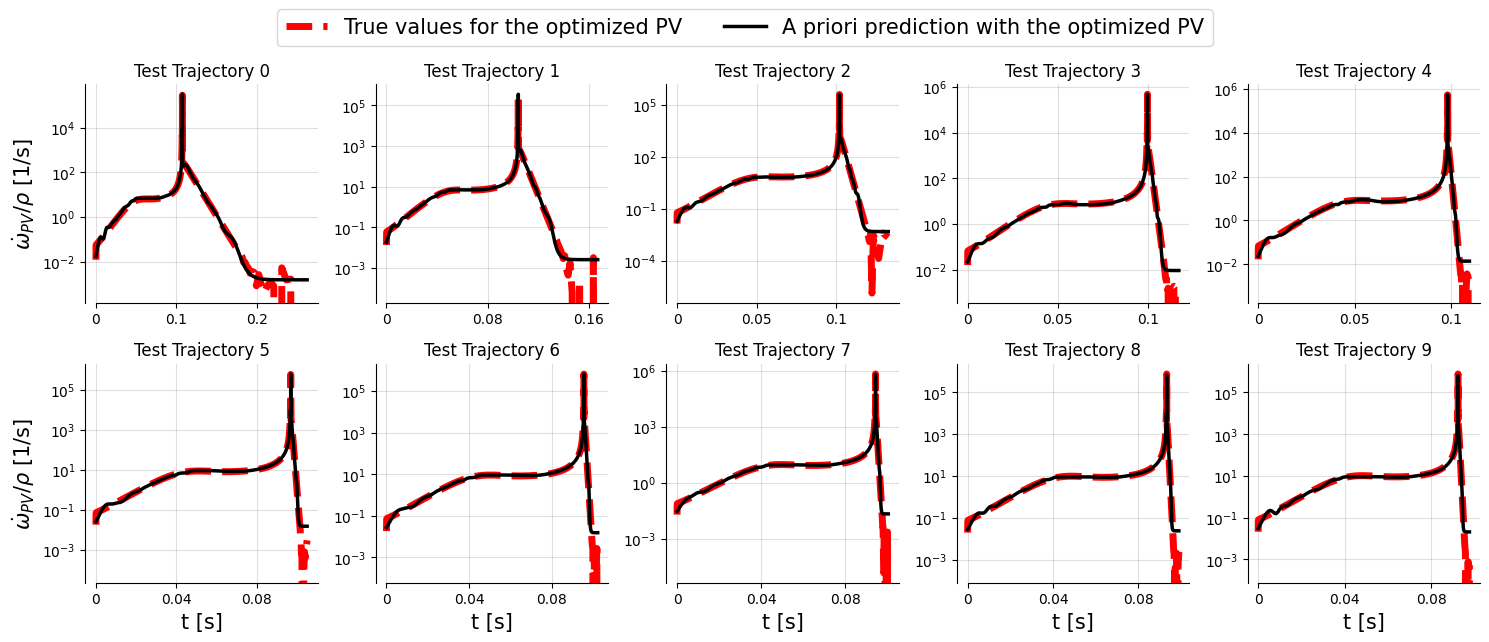

In [16]:
save = False
pathSave = "C:/Users/admin/Documents/PhD-ULB/Figures/2024-PV-optimization/Paper/EnergyAndAI/Supplementary-material/A posteriori/"
name = f"Apriori_ANN_{regression_modelname_optimized}.png"
namePdf = f"Apriori_ANN_{regression_modelname_optimized}.pdf"

num_test_trajectories = 10
rows, cols = 2, 5  # Arrange in a 2x5 grid

fig, axes = plt.subplots(rows, cols, figsize=(15, 6))  # Define the grid
axes = axes.flatten()  # Flatten to 1D array for easy indexing

def zero_formatter(x, pos):
    if x == 0:
        return "0"
    else:
        return f"{x:g}"

for i in range(num_test_trajectories):
    #test source terms
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-sources-test-trajectories.h5", 'r') as hf:
        test_trajectory_source = pd.DataFrame(hf[f'test_trajectory_{i}'][:], columns = state_space_names)
        state_space_source_test_DNS = test_trajectory_source[state_space_names_DNS].to_numpy()
        PV_optimized_source_test = PV_model.get_PV(torch.from_numpy(np.delete(state_space_source_test_DNS, idx_species_removed, axis=1))).detach().numpy()

    #test time trajectories
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}time-test-trajectories.h5", 'r') as hf:
        test_trajectory_time = pd.DataFrame(hf[f'test_trajectory_{i}'][:])
        
    ax = axes[i]
    ax.plot(test_trajectory_time, PV_optimized_source_test, label="True values for the optimized PV", color = "red", linestyle = "--", linewidth = 5)
    ax.plot(test_trajectory_time, prediction_test_trajectories_optimized[i], label="A priori prediction with the optimized PV", color = "k", linewidth = 2.5)
    ax.set_title(f"Test Trajectory {i}")
    ax.set_yscale("log")
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=3))
    ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=6))
    ax.grid(True, linestyle='-', alpha=0.4)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    xmin, xmax = ax.get_xlim()
    ax.spines["bottom"].set_bounds(0, xmax)

    ax.xaxis.set_major_formatter(FuncFormatter(zero_formatter))
    
    if(i>=num_test_trajectories-cols):
            ax.set_xlabel(f"t [s]", fontsize = 15)
    
    if(i%cols == 0):
            ax.set_ylabel(r'$\dot{\omega}_{PV} / \rho$ [1/s]', fontsize = 15)

#hide empty figures
for j in range(num_test_trajectories, len(axes)):
    axes[j].axis("off")

handles, labels = axes[0].get_legend_handles_labels()
custom_handles = [
    Line2D([0], [0], color=handle.get_color(),
           linestyle=handle.get_linestyle(),
           linewidth=handle.get_linewidth() * 1,  # Increase legend linewidth
           label=label)
    for handle, label in zip(handles, labels)
]
fig.legend(custom_handles, labels, loc='upper center', ncol=2, fontsize=15, frameon=True, bbox_to_anchor=(0.5, 1.08))

# Adjust layout
plt.tight_layout()
if(save):
    plt.savefig(pathSave + name, dpi=300, bbox_inches = "tight")
    plt.savefig(pathSave + namePdf, bbox_inches = "tight")
plt.show()

C:\Windows\Temp\ipykernel_29948\3596338826.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  greys = cm.get_cmap('Greys')


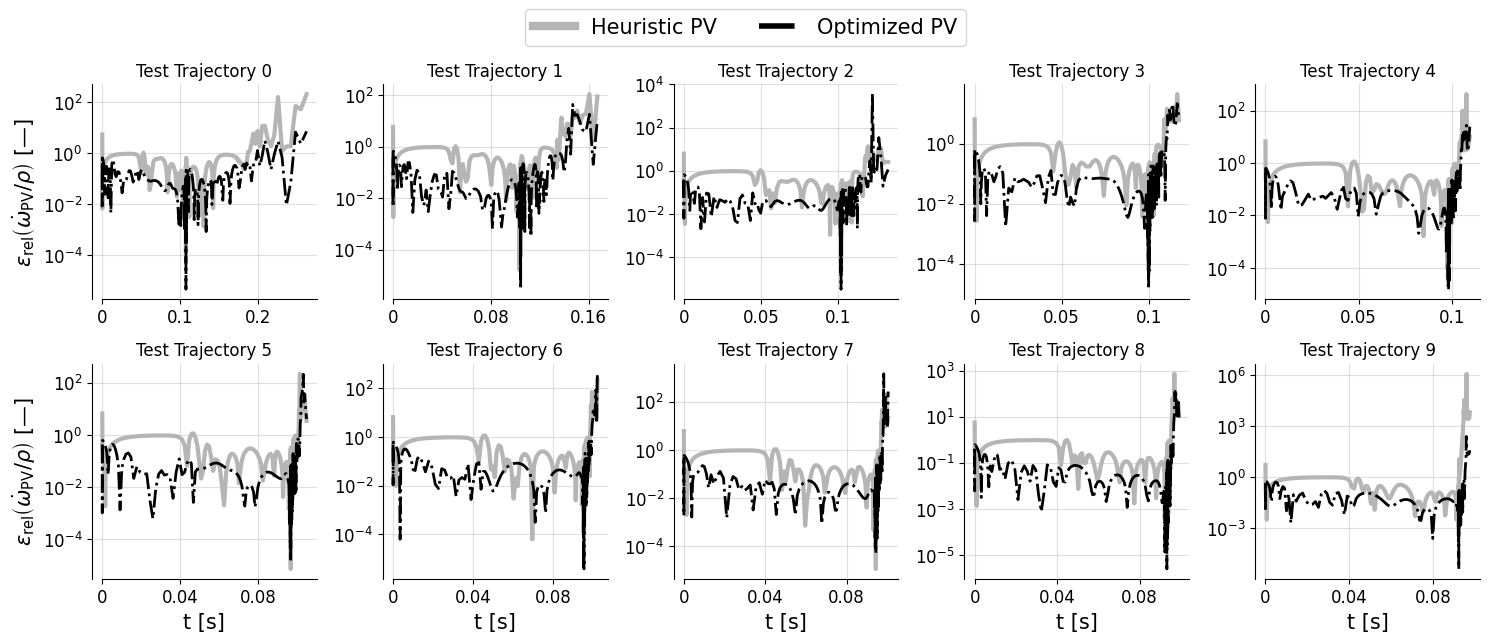

In [17]:
save = False
pathSave = "C:/Users/admin/Documents/PhD-ULB/Figures/2024-PV-optimization/Paper/EnergyAndAI/Supplementary-material/A posteriori/"
name = f"Heuristic vs optimized {id_model} - A priori - relative Error comparison - ANN"
namePdf = f"Heuristic vs optimized {id_model} - A priori - relative Error comparison - ANN.pdf"

num_test_trajectories = 10
rows, cols = 2, 5  # Arrange in a 2x5 grid

fig, axes = plt.subplots(rows, cols, figsize=(15, 6))  # Define the grid
axes = axes.flatten()  # Flatten to 1D array for easy indexing

greys = cm.get_cmap('Greys')

def zero_formatter(x, pos):
    if x == 0:
        return "0"
    else:
        return f"{x:g}"  # keeps original formatting for other ticks

for i in range(num_test_trajectories):
    #test source terms
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-sources-test-trajectories.h5", 'r') as hf:
        test_trajectory_source = pd.DataFrame(hf[f'test_trajectory_{i}'][:], columns = state_space_names)
        state_space_source_test_DNS = test_trajectory_source[state_space_names_DNS].to_numpy()
        PV_optimized_source_test = PV_model.get_PV(torch.from_numpy(np.delete(state_space_source_test_DNS, idx_species_removed, axis=1))).detach().numpy()
        
        PV_Xu_source_test = test_trajectory_source["H2O"] - test_trajectory_source["H2"] - test_trajectory_source["O2"]
        PV_Xu_source_test = PV_Xu_source_test.to_numpy()

    #test time trajectories
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}time-test-trajectories.h5", 'r') as hf:
        test_trajectory_time = pd.DataFrame(hf[f'test_trajectory_{i}'][:])
        
    ax = axes[i]
    relativeErrorXu = np.abs(PV_Xu_source_test.flatten() - prediction_test_trajectories[i].flatten())/np.abs(PV_Xu_source_test.flatten())
    relErrorOptimized = np.abs(prediction_test_trajectories_optimized[i].flatten() - PV_optimized_source_test.flatten())/np.abs(PV_optimized_source_test.flatten())
    ax.plot(test_trajectory_time, relativeErrorXu, label = "Heuristic PV", color = greys(0.4), linewidth = 3, linestyle = "-")
    ax.plot(test_trajectory_time, relErrorOptimized, label = "Optimized PV", color = "k", linewidth = 2, linestyle = "-.")
    ax.set_title(f"Test Trajectory {i}")
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=3))
    ax.set_yscale("log")
    ax.tick_params(axis='both', labelsize=12)
    ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=6))
    ax.grid(True, linestyle='-', alpha=0.4)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    xmin, xmax = ax.get_xlim()
    ax.spines["bottom"].set_bounds(0, xmax)
    
    ax.xaxis.set_major_formatter(FuncFormatter(zero_formatter))

    if(i>=num_test_trajectories-cols):
            ax.set_xlabel(f"t [s]", fontsize = 15)
    
    if(i%cols == 0):
            ax.set_ylabel(r"$\epsilon_{\mathrm{rel}}\left( \dot{\omega}_{\mathrm{PV}} / \rho \right)$" + " [\u2014]", fontsize=15)

handles, labels = axes[0].get_legend_handles_labels()
custom_handles = [
    Line2D([0], [0], color=handle.get_color(),
           linestyle=handle.get_linestyle(),
           linewidth=handle.get_linewidth() * 2,  # Increase legend linewidth
           label=label)
    for handle, label in zip(handles, labels)
]
fig.legend(custom_handles, labels, loc='upper center', ncol=2, fontsize=15, frameon=True, bbox_to_anchor=(0.5, 1.08))

#hide empty figures
for j in range(num_test_trajectories, len(axes)):
    axes[j].axis("off")

# Adjust layout
plt.tight_layout()
if(save):
    plt.savefig(pathSave + name, dpi=300, bbox_inches = "tight")
    plt.savefig(pathSave + namePdf, bbox_inches = "tight")
plt.show()

---
<h3> PV optimized: Evolve the PV over time

In [ ]:
class ODEOptimized(torch.nn.Module):

    def __init__(self, min_max_PV):
        super().__init__()
        self.min_PV = min_max_PV[0]
        self.max_PV = min_max_PV[1]

    def forward(self, t, y):
        y_scaled = y.clone() #avoid in place changes
        if scaledManifold_opt:
            y_scaled[1] = (y_scaled[1] - self.min_PV)/(self.max_PV - self.min_PV)
                       
        f_PV = (y_scaled-mins_input_optimized) / (maxs_input_optimized - mins_input_optimized) - 0.5
        PV_source_predicted = model_regression_optimized(f_PV)
        PV_source_predicted = (PV_source_predicted+1) /2 * (maxs_output_optimized - mins_output_optimized) + mins_output_optimized
        
        if(log_transform_opt == "continuous-symlog"):
            PV_optimized_source_test_predicted = inverse_symlog(PV_source_predicted, epsilon)
        elif(log_transform_opt == "log"):
            PV_optimized_source_test_predicted = 10**PV_source_predicted

        zero = torch.tensor([[0.0]], dtype=PV_optimized_source_test_predicted.dtype, device=PV_optimized_source_test_predicted.device)
        f_PV_source_predicted = torch.cat((zero, PV_optimized_source_test_predicted), dim=1) #add a zero for the mixture fraction

        return f_PV_source_predicted.squeeze()

In [19]:
idx_start_simulation = 0
list_simulations_optimized = []

#Get current date and time
now = datetime.now()
date_str = now.strftime("%Y-%m-%d")
time_str = now.strftime("%Hh%M")

print("Predicted")

for i in range(10):

    with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-test-trajectories.h5", 'r') as hf:
        test_trajectory = pd.DataFrame(hf[f'test_trajectory_{i}'][:], columns = state_space_names)
        state_space_test_DNS = test_trajectory[state_space_names_DNS].to_numpy()
        
        PV_optimized_test = PV_model.get_PV(torch.from_numpy(np.delete(state_space_test_DNS, idx_species_removed, axis=1))).detach().numpy()

        f_PV_optimized_test = np.hstack((np.full(PV_optimized_test.shape[0], mixture_fractions_test[i]).reshape(-1,1), PV_optimized_test.reshape(-1,1)))
        f_PV_optimized_test = torch.from_numpy(f_PV_optimized_test).clone().detach()

        
    #test time trajectories
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}time-test-trajectories.h5", 'r') as hf:
        test_trajectory_time = pd.DataFrame(hf[f'test_trajectory_{i}'][:])

    initial_condition = f_PV_optimized_test[idx_start_simulation,:]

    t_coordinates = test_trajectory_time[idx_start_simulation:].to_numpy().ravel()
    t_coordinates = torch.tensor(t_coordinates)
    
    ODEOptimized_instance = ODEOptimized([PV_optimized_test.min(), PV_optimized_test.max()])
    numerical_solution_optimized = odeint(ODEOptimized_instance, initial_condition, t_coordinates)#, method="rk4")
    list_simulations_optimized.append(numerical_solution_optimized) 

    MSE_optimized_test_simulation = mean_squared_error(PV_optimized_test[idx_start_simulation:], numerical_solution_optimized.squeeze()[:,1].detach().numpy())

    print(f"MSE for test trajectory {i}: {MSE_optimized_test_simulation}")

Predicted
MSE for test trajectory 0: 7.877221372146799
MSE for test trajectory 1: 13.926456565267479
MSE for test trajectory 2: 22.04926003790187
MSE for test trajectory 3: 26.767032670272737
MSE for test trajectory 4: 28.78203830412195
MSE for test trajectory 5: 25.480835140509917
MSE for test trajectory 6: 13.71512018809177
MSE for test trajectory 7: 18.219914532768392
MSE for test trajectory 8: 29.585384861673223
MSE for test trajectory 9: 34.042591660933134


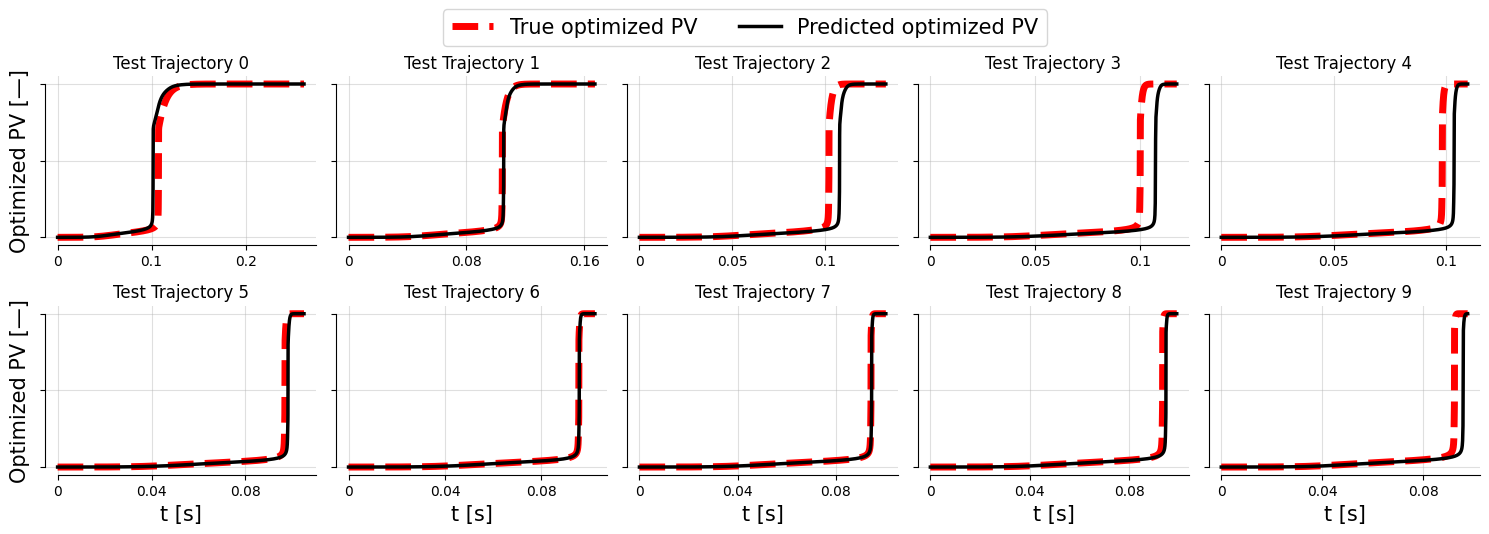

In [20]:
save = False
zoom = False
pathSave = "C:/Users/admin/Documents/PhD-ULB/Figures/2024-PV-optimization/Paper/EnergyAndAI/Supplementary-material/A posteriori/"


num_test_trajectories = 10
rows, cols = 2, 5  # Arrange in a 2x5 grid

fig, axes = plt.subplots(rows, cols, figsize=(15, 5))  # Define the grid
axes = axes.flatten()  # Flatten to 1D array for easy indexing

def zero_formatter(x, pos):
    if x == 0:
        return "0"
    else:
        return f"{x:g}"

for i in range(num_test_trajectories):
    #test state space
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-test-trajectories.h5", 'r') as hf:
        test_trajectory = pd.DataFrame(hf[f'test_trajectory_{i}'][:], columns = state_space_names)
        state_space_test_DNS = test_trajectory[state_space_names_DNS].to_numpy()
        PV_optimized_test = PV_model.get_PV(torch.from_numpy(np.delete(state_space_test_DNS, idx_species_removed, axis=1))).detach().numpy()

    #test time trajectories
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}time-test-trajectories.h5", 'r') as hf:
        test_trajectory_time = pd.DataFrame(hf[f'test_trajectory_{i}'][:])
        
    ax = axes[i]

    PV_min = PV_optimized_test[idx_start_simulation:].min()
    PV_max = PV_optimized_test[idx_start_simulation:].max()

    #-(list_simulations_optimized[i][:,1]-PV_min)/(PV_max - PV_min)+1

    if(zoom):
        ##############################################
        # Get the first and last index of the ignition
        ##############################################

        H2O_array = test_trajectory["H2O"].to_numpy()
        
        max_val = H2O_array.max()
        min_perc = 0.0028
        max_perc = 0.999
        lower_threshold = min_perc * max_val
        upper_threshold = max_perc * max_val

        idx_1 = np.searchsorted(H2O_array, lower_threshold, side='left')
        idx_99 = np.searchsorted(H2O_array, upper_threshold, side='left')

        ax.plot(test_trajectory_time[idx_1:idx_99], -(PV_optimized_test[idx_1:idx_99]-PV_min)/(PV_max - PV_min)+1, label="True optimized PV", color = "red", linestyle = "--", linewidth = 5) #id_end
        ax.plot(test_trajectory_time[idx_1:idx_99], -(list_simulations_optimized[i][idx_1:idx_99,1]-PV_min)/(PV_max - PV_min)+1, label="Predicted optimized PV", color = "k", linewidth = 2.5) #idx_end-idx_start_simulation
    else:
        ax.plot(test_trajectory_time[idx_start_simulation:], (PV_optimized_test[idx_start_simulation:]-PV_min)/(PV_max - PV_min), label="True optimized PV", color = "red", linestyle = "--", linewidth = 5) #id_end
        ax.plot(test_trajectory_time[idx_start_simulation:], (list_simulations_optimized[i][:,1].detach().numpy()-PV_min)/(PV_max - PV_min), label="Predicted optimized PV", color = "k", linewidth = 2.5) #idx_end-idx_start_simulation
    
    ax.set_title(f"Test Trajectory {i}")
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=3))
    ax.set_yticks([0, 0.5, 1])
    ax.set_yticklabels([])

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    xmin, xmax = ax.get_xlim()
    ax.spines["bottom"].set_bounds(0, xmax)

    ax.spines["left"].set_bounds(0, 1)

    ax.xaxis.set_major_formatter(FuncFormatter(zero_formatter))

    ax.grid(True, linestyle='-', alpha=0.4)

    if(i>=num_test_trajectories-cols):
            ax.set_xlabel(f"t [s]", fontsize = 15)
    
    if(i%cols == 0):
            ax.set_ylabel('Optimized PV [\u2014]', fontsize = 15)    

#hide empty figures
for j in range(num_test_trajectories, len(axes)):
    axes[j].axis("off")

handles, labels = axes[0].get_legend_handles_labels()
custom_handles = [
    Line2D([0], [0], color=handle.get_color(),
           linestyle=handle.get_linestyle(),
           linewidth=handle.get_linewidth() * 1,  # Increase legend linewidth
           label=label)
    for handle, label in zip(handles, labels)
]
fig.legend(custom_handles, labels, loc='upper center', ncol=2, fontsize=15, frameon=True, bbox_to_anchor=(0.5, 1.08))

name = f"Heuristic vs optimized {id_model} - A posteriori - Optimized PV - ANN {regression_modelname_optimized}{f' - zoom {min_perc}-{max_perc}' if zoom else ''}.png"
namePdf = f"Heuristic vs optimized {id_model} - A posteriori - Optimized PV - ANN {regression_modelname_optimized}{f' - zoom {min_perc}-{max_perc}' if zoom else ''}.pdf"

# Adjust layout
plt.tight_layout()
if(save):
    plt.savefig(pathSave + name, dpi=300, bbox_inches = "tight")
    plt.savefig(pathSave + namePdf, bbox_inches = "tight")
plt.show()

<h3> Run the a posteriori simulation longer

In [21]:
list_simulations_optimized_ext = []

#Get current date and time
now = datetime.now()
date_str = now.strftime("%Y-%m-%d")
time_str = now.strftime("%Hh%M")

print("Predicted")

for i in range(10):

    with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-test-trajectories.h5", 'r') as hf:
        test_trajectory = pd.DataFrame(hf[f'test_trajectory_{i}'][:], columns = state_space_names)
        state_space_test_DNS = test_trajectory[state_space_names_DNS].to_numpy()
        
        PV_optimized_test = PV_model.get_PV(torch.from_numpy(np.delete(state_space_test_DNS, idx_species_removed, axis=1))).detach().numpy()

        f_PV_optimized_test = np.hstack((np.full(PV_optimized_test.shape[0], mixture_fractions_test[i]).reshape(-1,1), PV_optimized_test.reshape(-1,1)))
        f_PV_optimized_test = torch.from_numpy(f_PV_optimized_test).clone().detach()

        
    #test time trajectories
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}time-test-trajectories.h5", 'r') as hf:
        test_trajectory_time = pd.DataFrame(hf[f'test_trajectory_{i}'][:])

    initial_condition = f_PV_optimized_test[0,:]

    t_coordinates = test_trajectory_time[0:].to_numpy().ravel()
    t_coordinates = torch.tensor(t_coordinates)
    deltaTime = t_coordinates[-1] - t_coordinates[-2]

    last_value = t_coordinates[-1]
    new_times = []

    next_time = last_value + deltaTime
    while next_time <= 2:
        new_times.append(next_time.item())
        next_time += deltaTime

    #Add extension to the current tensor
    if new_times:
        extension = torch.tensor(new_times, dtype=torch.float32)
        t_coordinates = torch.cat((t_coordinates, extension))
    
    ODEOptimized_instance = ODEOptimized([PV_optimized_test.min(), PV_optimized_test.max()])
    numerical_solution_optimized = odeint(ODEOptimized_instance, initial_condition, t_coordinates)#, method="rk4")
    list_simulations_optimized_ext.append(numerical_solution_optimized) 

Predicted


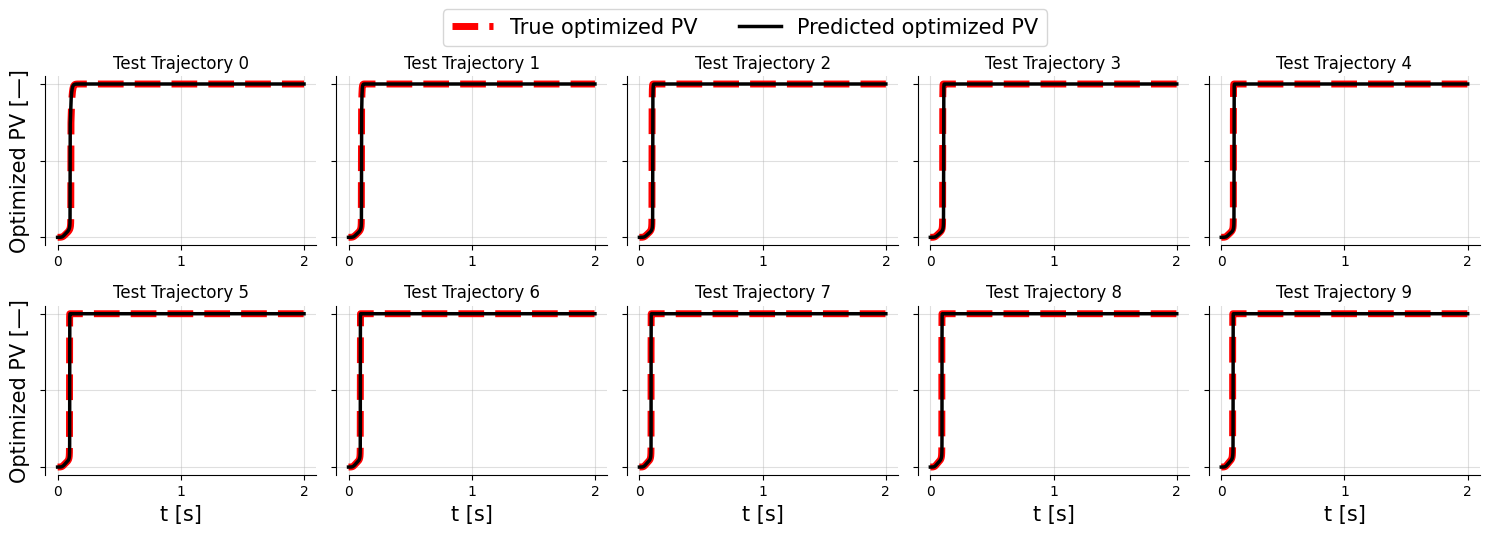

In [22]:
save = False
pathSave = "C:/Users/admin/Documents/PhD-ULB/Figures/2024-PV-optimization/Paper/EnergyAndAI/Supplementary-material/A posteriori/"
name = f"Heuristic vs optimized - A posteriori - Optimized PV - ANN {regression_modelname_optimized}{f' - zoom {min_perc}-{max_perc}' if zoom else ''}_timeExt.png"
namePdf = f"Heuristic vs optimized - A posteriori - Optimized PV - ANN {regression_modelname_optimized}{f' - zoom {min_perc}-{max_perc}' if zoom else ''}_timeExt.pdf"

num_test_trajectories = 10
rows, cols = 2, 5  # Arrange in a 2x5 grid

fig, axes = plt.subplots(rows, cols, figsize=(15, 5))  # Define the grid
axes = axes.flatten()  # Flatten to 1D array for easy indexing

for i in range(10):
    #test state space
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-test-trajectories.h5", 'r') as hf:
        test_trajectory = pd.DataFrame(hf[f'test_trajectory_{i}'][:], columns = state_space_names)
        state_space_test_DNS = test_trajectory[state_space_names_DNS].to_numpy()
        PV_optimized_test = PV_model.get_PV(torch.from_numpy(np.delete(state_space_test_DNS, idx_species_removed, axis=1))).detach().numpy()

    #test time trajectories
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}time-test-trajectories.h5", 'r') as hf:
        test_trajectory_time = pd.DataFrame(hf[f'test_trajectory_{i}'][:])
    
    test_trajectory_time = test_trajectory_time.to_numpy().ravel()
    test_trajectory_time = torch.tensor(test_trajectory_time)
    deltaTime = test_trajectory_time[-1] - test_trajectory_time[-2]

    last_value = test_trajectory_time[-1]
    new_times = []

    next_time = last_value + deltaTime
    while next_time <= 2:
        new_times.append(next_time.item())
        next_time += deltaTime

    #Add extension to the current tensor
    if new_times:
        extension = torch.tensor(new_times, dtype=torch.float32)
        test_trajectory_time_ext = torch.cat((test_trajectory_time, extension))

        last_value = PV_optimized_test[-1]
        extension = np.tile(last_value, (len(new_times), 1))  #extension with last value of PV_optimized_test
        PV_optimized_test_ext = np.vstack((PV_optimized_test, extension)) #concatenate the extension with the original value
    
    min_PV = PV_optimized_test.min()
    max_PV = PV_optimized_test.max()
    
    ax = axes[i]
    ax.plot(test_trajectory_time_ext, (PV_optimized_test_ext-min_PV)/(max_PV-min_PV), label="True optimized PV", color = "red", linestyle = "--", linewidth = 5) #id_end
    ax.plot(test_trajectory_time_ext, (list_simulations_optimized_ext[i].squeeze()[:,1].detach().numpy()-min_PV)/(max_PV-min_PV), label="Predicted optimized PV", color = "k", linewidth = 2.5) #idx_end-idx_start_simulation
    ax.set_title(f"Test Trajectory {i}")
    ax.set_xticks([0, 1 , 2])
    ax.set_yticks([0, 0.5, 1])
    ax.set_yticklabels([])

    ax.grid(True, linestyle='-', alpha=0.4)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    xmin, xmax = ax.get_xlim()
    ax.spines["bottom"].set_bounds(0, xmax)

    if(i>=num_test_trajectories-cols):
            ax.set_xlabel(f"t [s]", fontsize = 15)
    
    if(i%cols == 0):
            ax.set_ylabel('Optimized PV [\u2014]', fontsize = 15)    

#hide empty figures
for j in range(num_test_trajectories, len(axes)):
    axes[j].axis("off")

handles, labels = axes[0].get_legend_handles_labels()
custom_handles = [
    Line2D([0], [0], color=handle.get_color(),
           linestyle=handle.get_linestyle(),
           linewidth=handle.get_linewidth() * 1,  # Increase legend linewidth
           label=label)
    for handle, label in zip(handles, labels)
]
fig.legend(custom_handles, labels, loc='upper center', ncol=2, fontsize=15, frameon=True, bbox_to_anchor=(0.5, 1.08))

# Adjust layout
plt.tight_layout()
if(save):
    plt.savefig(pathSave + name, dpi=300, bbox_inches = "tight")
    plt.savefig(pathSave + namePdf, bbox_inches = "tight")
plt.show()

---
## Compute a posteriori PV source term

In [92]:
idx_traj = 4

#test source terms
with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-test-trajectories.h5", 'r') as hf:
    test_trajectory = pd.DataFrame(hf[f'test_trajectory_{idx_traj}'][:], columns = state_space_names)
    PV_Xu_test = test_trajectory["H2O"] - test_trajectory["H2"] - test_trajectory["O2"]
    PV_Xu_test = PV_Xu_test.to_numpy().reshape(-1,1)

PV_Xu_test_min = PV_Xu_test.min()
PV_Xu_test_max = PV_Xu_test.max()


y_scaled = list_simulations_Xu[idx_traj].clone()

if scaledManifold_Xu:
    y_scaled[:, 1] = (y_scaled[:, 1] - PV_Xu_test_min)/(PV_Xu_test_max - PV_Xu_test_min)

f_PV = (torch.Tensor(y_scaled)-mins_input_Xu) / (maxs_input_Xu - mins_input_Xu) - 0.5
PV_source_predicted = model_regression_Xu(f_PV)
PV_source_predicted = (PV_source_predicted+1) /2 * (maxs_output_Xu - mins_output_Xu) + mins_output_Xu

if(log_transform == "continuous-symlog"):
    PV_source_predicted = inverse_symlog(PV_source_predicted, epsilon)
elif(log_transform == "log"):
    PV_source_predicted = 10**PV_source_predicted

PV_source_Xu_pred_aPost_4 = PV_source_predicted

In [99]:
idx_traj = 4
with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-test-trajectories.h5", 'r') as hf:
    test_trajectory = pd.DataFrame(hf[f'test_trajectory_{idx_traj}'][:], columns = state_space_names)
    state_space_test_DNS = test_trajectory[state_space_names_DNS].to_numpy()
    PV_optimized_test = PV_model.get_PV(torch.from_numpy(np.delete(state_space_test_DNS, idx_species_removed, axis=1))).detach().numpy()

PV_optimized_test_min = PV_optimized_test[idx_start_simulation:].min()
PV_optimized_test_max = PV_optimized_test[idx_start_simulation:].max()

y_scaled = list_simulations_optimized[idx_traj].clone() #avoid in place changes
if scaledManifold_opt:
    y_scaled[:, 1] = (y_scaled[:, 1] - PV_optimized_test_min)/(PV_optimized_test_max - PV_optimized_test_min)
                
f_PV = (y_scaled - mins_input_optimized) / (maxs_input_optimized - mins_input_optimized) - 0.5
PV_source_predicted = model_regression_optimized(f_PV)
PV_source_predicted = (PV_source_predicted+1) /2 * (maxs_output_optimized - mins_output_optimized) + mins_output_optimized

if(log_transform_opt == "continuous-symlog"):
    PV_optimized_source_test_predicted = inverse_symlog(PV_source_predicted, epsilon)
elif(log_transform_opt == "log"):
    PV_optimized_source_test_predicted = 10**PV_source_predicted

PV_source_optimized_pred_aPost_4 = PV_optimized_source_test_predicted

---
## Do the error accumulation analysis

(2406,)
(2406,)


C:\Windows\Temp\ipykernel_29948\1215847146.py:107: RuntimeWarning: invalid value encountered in divide
  axs[3].plot(test_trajectory_time, (PV_Xu_true_scaled - PV_Xu_pred_scaled)/PV_Xu_true_scaled, label = "Heuristic PV", color = greys(0.4), linewidth = 3, linestyle = "-")
C:\Windows\Temp\ipykernel_29948\1215847146.py:108: RuntimeWarning: invalid value encountered in divide
  axs[3].plot(test_trajectory_time, (PV_optimized_true_scaled - PV_optimized_pred_scaled)/PV_optimized_true_scaled, label = "Optimized PV", color = "k", linewidth = 2, linestyle = "-.")


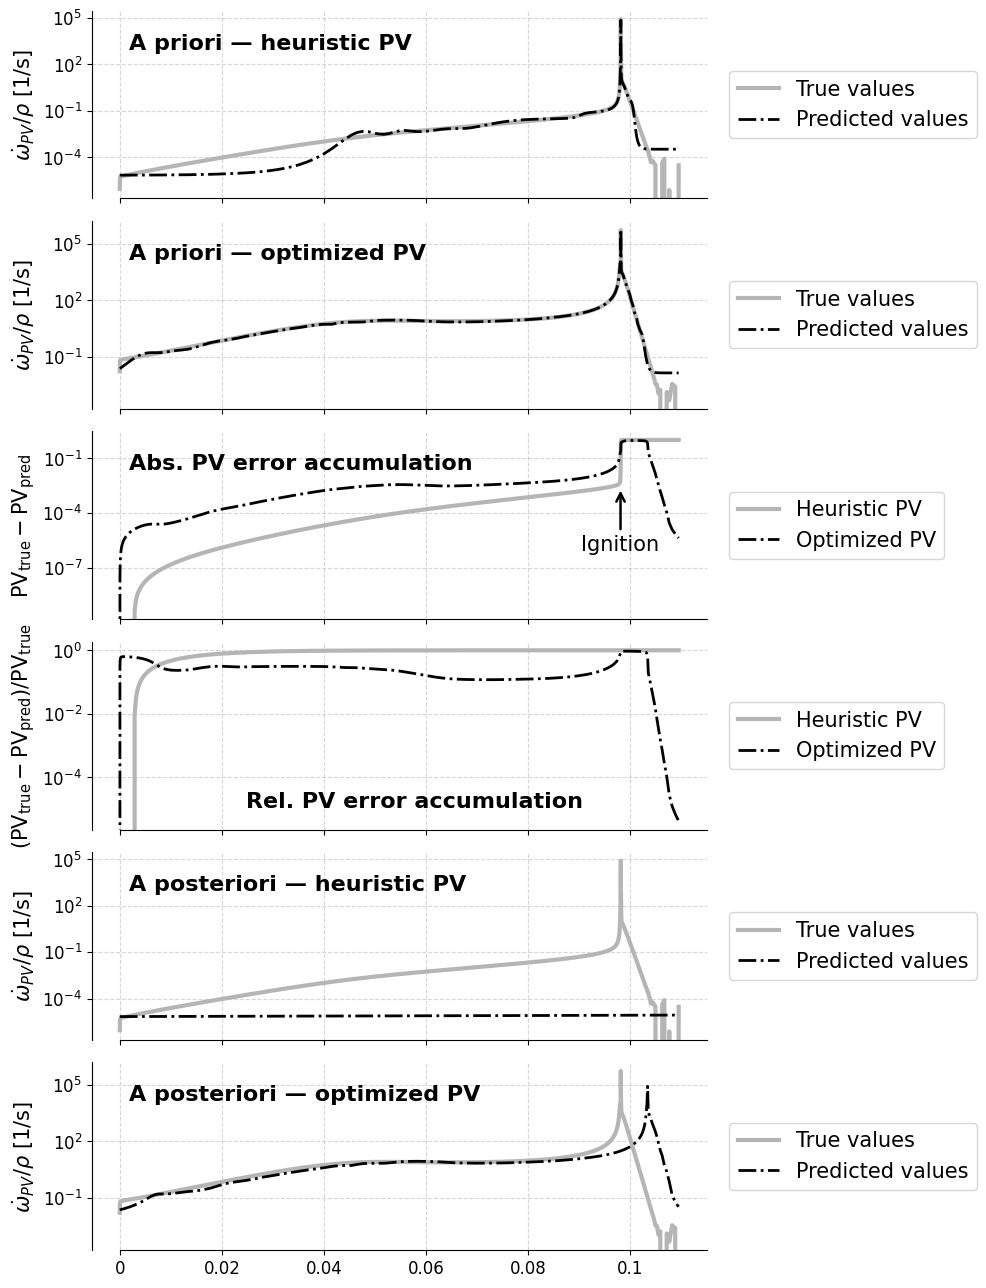

In [119]:
idx_traj = 4
save = True
pathSave = "C:/Users/admin/Documents/PhD-ULB/Figures/2024-PV-optimization/Paper/EnergyAndAI/Supplementary-material/A posteriori/Error accumulation/"
name = f"Error accumulation analaysis - traj {idx_traj} - H2O-H2-O2 vs optimized"
namePdf = f"Error accumulation analaysis - traj {idx_traj} - H2O-H2-O2 vs optimized.pdf"

#test source terms
with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-test-trajectories.h5", 'r') as hf:
    test_trajectory = pd.DataFrame(hf[f'test_trajectory_{idx_traj}'][:], columns = state_space_names)
    PV_Xu_test = test_trajectory["H2O"] - test_trajectory["H2"] - test_trajectory["O2"]
    PV_Xu_test = PV_Xu_test.to_numpy().reshape(-1,1)
    f_PV_Xu_test = np.hstack((np.full(PV_Xu_test.shape[0], mixture_fractions_test[idx_traj]).reshape(-1,1), PV_Xu_test))

    state_space_test_DNS = test_trajectory[state_space_names_DNS].to_numpy()
    PV_optimized_test = PV_model.get_PV(torch.from_numpy(np.delete(state_space_test_DNS, idx_species_removed, axis=1))).detach().numpy()

with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-sources-test-trajectories.h5", 'r') as hf:
        test_trajectory_source = pd.DataFrame(hf[f'test_trajectory_{idx_traj}'][:], columns = state_space_names)
        PV_Xu_source_test = test_trajectory_source["H2O"] - test_trajectory_source["H2"] - test_trajectory_source["O2"]
        PV_Xu_source_test = PV_Xu_source_test.to_numpy()

        state_space_source_test_DNS = test_trajectory_source[state_space_names_DNS].to_numpy()
        PV_optimized_source_test = PV_model.get_PV(torch.from_numpy(np.delete(state_space_source_test_DNS, idx_species_removed, axis=1))).detach().numpy()

#test time trajectories
with h5py.File(f"{path_data_autoignition}{filename_autoignition}time-test-trajectories.h5", 'r') as hf:
    test_trajectory_time = pd.DataFrame(hf[f'test_trajectory_{idx_traj}'][:])

PV_Xu_test_min = PV_Xu_test.min()
PV_Xu_test_max = PV_Xu_test.max()

PV_optimized_test_min = PV_optimized_test[idx_start_simulation:].min()
PV_optimized_test_max = PV_optimized_test[idx_start_simulation:].max()

fig, axs = plt.subplots(nrows=6, ncols=1, figsize=(10, 13), sharex=True)

PV_Xu_true_scaled = ((PV_Xu_test[:] - PV_Xu_test_min)/(PV_Xu_test_max - PV_Xu_test_min)).flatten()
PV_Xu_pred_scaled = (list_simulations_Xu[idx_traj][:,1].detach().numpy() - PV_Xu_test_min)/(PV_Xu_test_max - PV_Xu_test_min)

PV_optimized_true_scaled = ((PV_optimized_test[idx_start_simulation:]-PV_optimized_test_min)/(PV_optimized_test_max - PV_optimized_test_min)).flatten()
PV_optimized_pred_scaled = (list_simulations_optimized[idx_traj][:,1].detach().numpy()-PV_optimized_test_min)/(PV_optimized_test_max - PV_optimized_test_min)

print(PV_optimized_true_scaled.shape)
print(PV_optimized_pred_scaled.shape)

def zero_formatter(x, pos):
    if x == 0:
        return "0"
    else:
        return f"{x:g}"

# --- First subplot ---
axs[0].plot(test_trajectory_time, PV_Xu_source_test, label = "True values", color = greys(0.4), linewidth = 3, linestyle = "-")
axs[0].plot(test_trajectory_time, prediction_test_trajectories[idx_traj], label = "Predicted values", color = "k", linewidth = 2, linestyle = "-.")

axs[0].set_ylabel(r"$\dot{\omega}_{PV} / \rho$ [1/s]", fontsize=15)
axs[0].set_yscale("log")
axs[0].legend(
    fontsize=15,
    ncols=1,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5)
)
axs[0].grid(True, which="both", linestyle="--", alpha=0.5)

# --- Second subplot ---
axs[1].plot(test_trajectory_time, PV_optimized_source_test, label = "True values", color = greys(0.4), linewidth = 3, linestyle = "-")
axs[1].plot(test_trajectory_time, prediction_test_trajectories_optimized[idx_traj], label = "Predicted values", color = "k", linewidth = 2, linestyle = "-.")

axs[1].set_ylabel(r"$\dot{\omega}_{PV} / \rho$ [1/s]", fontsize=15)
axs[1].set_yscale("log")
axs[1].legend(
    fontsize=15,
    ncols=1,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5)
)
axs[1].grid(True, which="both", linestyle="--", alpha=0.5)

# --- Third subplot ---
axs[2].plot(test_trajectory_time, (PV_Xu_true_scaled - PV_Xu_pred_scaled), label = "Heuristic PV", color = greys(0.4), linewidth = 3, linestyle = "-")
axs[2].plot(test_trajectory_time, (PV_optimized_true_scaled - PV_optimized_pred_scaled), label = "Optimized PV", color = "k", linewidth = 2, linestyle = "-.")

axs[2].set_ylabel(r"$\mathrm{PV}_{\mathrm{true}} - \mathrm{PV}_{\mathrm{pred}}$", fontsize=15)
axs[2].set_yscale("log")
axs[2].legend(
    fontsize=15,
    ncols=1,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5)
)
axs[2].grid(True, which="both", linestyle="--", alpha=0.5)

axs[2].annotate(
            "Ignition",
            fontsize=15,
            ha="center",
            va="top",
            xy=(0.86, 0.7),
            xytext=(0.86, 0.45), #0.229
            xycoords=axs[2].transAxes,
            textcoords=axs[2].transAxes,
            arrowprops=dict(arrowstyle="->", linewidth=1.8)
        )

# --- Third subplot ---
axs[3].plot(test_trajectory_time, (PV_Xu_true_scaled - PV_Xu_pred_scaled)/PV_Xu_true_scaled, label = "Heuristic PV", color = greys(0.4), linewidth = 3, linestyle = "-")
axs[3].plot(test_trajectory_time, (PV_optimized_true_scaled - PV_optimized_pred_scaled)/PV_optimized_true_scaled, label = "Optimized PV", color = "k", linewidth = 2, linestyle = "-.")

axs[3].set_ylabel(r"$(\mathrm{PV}_{\mathrm{true}} - \mathrm{PV}_{\mathrm{pred}})/\mathrm{PV}_{\mathrm{true}}$", fontsize=15)
axs[3].set_yscale("log")
axs[3].legend(
    fontsize=15,
    ncols=1,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5)
)
axs[3].grid(True, which="both", linestyle="--", alpha=0.5)

# --- Fifth subplot ---
axs[4].plot(test_trajectory_time, PV_Xu_source_test, label = "True values", color = greys(0.4), linewidth = 3, linestyle = "-")
axs[4].plot(test_trajectory_time, PV_source_Xu_pred_aPost_4.detach().numpy(), label = "Predicted values", color = "k", linewidth = 2, linestyle = "-.")

axs[4].set_ylabel(r"$\dot{\omega}_{PV} / \rho$ [1/s]", fontsize=15)
axs[4].set_yscale("log")
axs[4].legend(
    fontsize=15,
    ncols=1,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5)
)
axs[4].grid(True, which="both", linestyle="--", alpha=0.5)

# --- Sixth subplot ---
axs[5].plot(test_trajectory_time, PV_optimized_source_test, label = "True values", color = greys(0.4), linewidth = 3, linestyle = "-")
axs[5].plot(test_trajectory_time, PV_source_optimized_pred_aPost_4.detach().numpy(), label = "Predicted values", color = "k", linewidth = 2, linestyle = "-.")

axs[5].set_ylabel(r"$\dot{\omega}_{PV} / \rho$ [1/s]", fontsize=15)
axs[5].set_yscale("log")
axs[5].legend(
    fontsize=15,
    ncols=1,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5)
)
axs[5].grid(True, which="both", linestyle="--", alpha=0.5)
axs[5].tick_params(axis='x', labelsize=12)
axs[5].xaxis.set_major_formatter(FuncFormatter(zero_formatter))

axs[0].text(0.06, 0.88, "A priori \u2014 heuristic PV", transform=axs[0].transAxes,
            fontsize=16, fontweight='bold', verticalalignment='top', horizontalalignment='left')

axs[1].text(0.06, 0.88, "A priori \u2014 optimized PV", transform=axs[1].transAxes,
            fontsize=16, fontweight='bold', verticalalignment='top', horizontalalignment='left')

axs[2].text(0.06, 0.88, "Abs. PV error accumulation", transform=axs[2].transAxes,
            fontsize=16, fontweight='bold', verticalalignment='top', horizontalalignment='left')

axs[3].text(0.25, 0.2, "Rel. PV error accumulation", transform=axs[3].transAxes,
            fontsize=16, fontweight='bold', verticalalignment='top', horizontalalignment='left')

axs[4].text(0.06, 0.88, "A posteriori \u2014 heuristic PV", transform=axs[4].transAxes,
            fontsize=16, fontweight='bold', verticalalignment='top', horizontalalignment='left')

axs[5].text(0.06, 0.88, "A posteriori \u2014 optimized PV", transform=axs[5].transAxes,
            fontsize=16, fontweight='bold', verticalalignment='top', horizontalalignment='left')

for i in range(6):
    axs[i].spines['top'].set_visible(False)
    axs[i].spines['right'].set_visible(False)

    xmin, xmax = axs[i].get_xlim()
    axs[i].spines["bottom"].set_bounds(0, xmax)

    axs[i].tick_params(axis='y', labelsize=12)

plt.tight_layout()
if(save):
    plt.savefig(pathSave + name, dpi=300, bbox_inches = "tight")
    plt.savefig(pathSave + namePdf, bbox_inches = "tight")
plt.show()